# Laboratorio 9 — Significancia estadística de una correlación

## 1. Objetivo

Aplicar una prueba de hipótesis para determinar si una correlación observada en una muestra proporciona evidencia estadística suficiente de una asociación lineal en la población.

En este laboratorio continuaremos trabajando con el conjunto de datos **Auto MPG**.

El análisis seguirá las etapas fundamentales de una prueba de hipótesis:

1. Formular $$(H_0)$$ y $$(H_1).$$
2. Establecer el nivel de significancia $$(alpha).$$
3. Calcular el coeficiente de correlación y el p-value.
4. Comparar el p-value con $$(alpha).$$
5. Tomar una decisión sobre $$(H_0).$$
6. Interpretar el resultado en el contexto del problema.

## Librerías utilizadas

Para el desarrollo del laboratorio utilizaremos:

- **Pandas (`pandas`)**: carga, organización y preparación de los datos.
- **Matplotlib (`matplotlib.pyplot`)**: creación y personalización de gráficos.
- **Seaborn (`seaborn`)**: generación de visualizaciones estadísticas y líneas de regresión.
- **SciPy (`scipy.stats`)**: herramientas estadísticas; utilizaremos `pearsonr()` para calcular la correlación de Pearson y su p-value.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
df = pd.read_csv("/content/auto-mpg.csv")
df["horsepower"] = pd.to_numeric(
    df["horsepower"],
    errors="coerce"
)
df = df.dropna(subset=["horsepower"]).copy()
print("Número de observaciones:", len(df))
df.head()

Número de observaciones: 392


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


### Formulación de las hipótesis

A partir del problema planteado, formule las hipótesis necesarias para evaluar si existe una correlación lineal entre `weight` y `mpg` en la población.

**Preguntas:**

1. ¿Cuál es la hipótesis nula? $$H_0$$
2. ¿Cuál es la hipótesis alternativa? $$H_1$$
3. ¿La prueba planteada es bilateral o unilateral? Justifique brevemente.

## 4. Nivel de significancia

Antes de calcular la prueba estadística, establecemos un nivel de significancia de:

$$
\alpha = 0.05
$$

Utilizaremos este valor como criterio para tomar la decisión:

- Si $p\text{-value} \leq 0.05$, **rechazamos $H_0$**.
- Si $p\text{-value} > 0.05$, **no rechazamos $H_0$**.

A continuación, calcularemos el coeficiente de correlación de Pearson y su p-value.

In [ ]:
r, p_value = pearsonr(
    df["weight"],
    df["mpg"]
)
print("Coeficiente de Pearson:", round(r, 4))
print("p-value:", p_value)

Coeficiente de Pearson: -0.8322
p-value: 6.01529605143857e-102


### Análisis de los resultados

Observe los valores obtenidos para el coeficiente de Pearson y el p-value.

**Preguntas:**

1. ¿Qué indica el valor $r=-0.8322$ sobre la dirección y la intensidad de la relación entre `weight` y `mpg`?

2. Compare el p-value obtenido con el nivel de significancia $\alpha=0.05$. ¿Cuál es menor?

3. De acuerdo con la regla de decisión, ¿se debe rechazar o no rechazar $H_0$?

4. ¿Qué implica esta decisión respecto a la significancia estadística de la correlación entre `weight` y `mpg`?

## 5. Decisión estadística

La función `pearsonr()` nos proporciona dos resultados:

- $r$: indica la dirección y la intensidad de la correlación lineal.
- `p-value`: permite evaluar la evidencia estadística contra la hipótesis nula.

Recordemos que establecimos:

$$
\alpha = 0.05
$$

Ahora debemos comparar el p-value obtenido con $\alpha$ para decidir si rechazamos o no rechazamos $H_0$.

La regla de decisión es:

- Si $p\text{-value} \leq \alpha$, **rechazamos $H_0$**.
- Si $p\text{-value} > \alpha$, **no rechazamos $H_0$**.

En este caso, como $\alpha=0.05$, compararemos directamente el p-value obtenido con $0.05$.

In [ ]:
alpha = 0.05
print("Coeficiente de Pearson:", round(r, 4))
print("p-value:", p_value)
print("Nivel de significancia:", alpha)
if p_value <= alpha:
    print("\nDecisión: Rechazar H0")
else:
    print("\nDecisión: No rechazar H0")

Coeficiente de Pearson: -0.8322
p-value: 6.01529605143857e-102
Nivel de significancia: 0.05

Decisión: Rechazar H0


###  Interpretación de la decisión

El código comparó automáticamente el p-value con el nivel de significancia $\alpha=0.05$ y produjo la decisión estadística.

**Preguntas:**

1. ¿Por qué el código tomó la decisión de rechazar $H_0$?

2. ¿Qué significa rechazar $H_0$ en este problema?

3. ¿Podemos afirmar que la correlación entre `weight` y `mpg` es estadísticamente significativa? Justifique.

4. ¿Este resultado permite afirmar que el peso del automóvil causa una disminución en el rendimiento de combustible? Explique.

## 6. Intensidad de la correlación y significancia estadística

En el análisis anterior encontramos una correlación negativa fuerte y estadísticamente significativa entre `weight` y `mpg`.

Ahora analizaremos la relación entre:

- `mpg`: rendimiento de combustible en millas por galón.
- `acceleration`: aceleración del automóvil.

El objetivo es determinar si una correlación de menor intensidad también puede ser estadísticamente significativa.

Planteamos nuevamente:

$$
H_0:\rho=0
$$

$$
H_1:\rho\neq0
$$

y mantenemos un nivel de significancia de:

$$
\alpha=0.05
$$

In [ ]:
r_acc, p_acc = pearsonr(
    df["mpg"],
    df["acceleration"]
)
print("Coeficiente de Pearson:", round(r_acc, 4))
print("p-value:", p_acc)
if p_acc <= alpha:
    print("\nDecisión: Rechazar H0")
else:
    print("\nDecisión: No rechazar H0")

Coeficiente de Pearson: 0.4233
p-value: 1.7785761248041713e-18

Decisión: Rechazar H0


### Análisis del segundo caso

Compare estos resultados con los obtenidos anteriormente para `weight` y `mpg`.

**Preguntas:**

1. ¿Qué indica el valor $r=0.4233$ sobre la dirección y la intensidad de la relación entre `mpg` y `acceleration`?

2. ¿El p-value obtenido es menor o mayor que $\alpha=0.05$?

3. ¿Por qué se rechazó $H_0$?

4. ¿La correlación entre `mpg` y `acceleration` es estadísticamente significativa?

5. Compare este resultado con la correlación entre `weight` y `mpg`, donde se obtuvo $r=-0.8322$. ¿Una correlación necesita ser fuerte para ser estadísticamente significativa?

## 7. Visualización de las relaciones analizadas

Para complementar la prueba de hipótesis, visualizaremos las dos relaciones estudiadas mediante diagramas de dispersión y una línea de regresión lineal.

En cada gráfico se mostrarán:

- Las observaciones de la muestra.
- La tendencia lineal estimada.
- El coeficiente de correlación de Pearson ($r$).
- El p-value asociado a la prueba de significancia.

Esto permite relacionar visualmente la **forma de la asociación**, su **intensidad** y su **significancia estadística**.

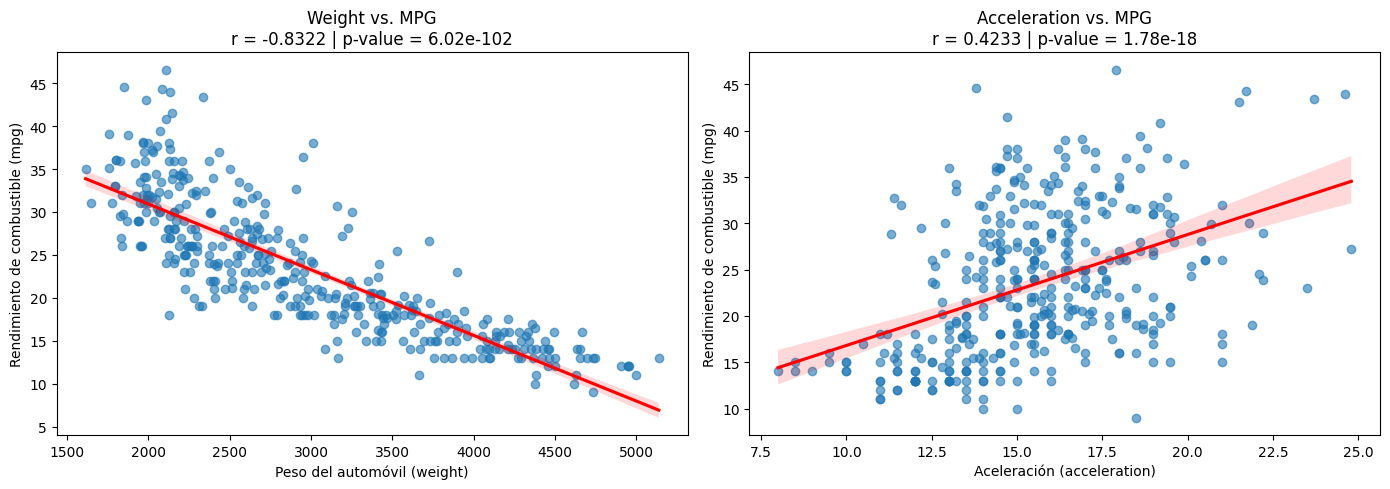

In [ ]:
r1, p1 = pearsonr(df["weight"], df["mpg"])
r2, p2 = pearsonr(df["acceleration"], df["mpg"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(
    data=df,
    x="weight",
    y="mpg",
    ax=axes[0],
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
axes[0].set_title(
    f"Weight vs. MPG\nr = {r1:.4f} | p-value = {p1:.2e}"
)
axes[0].set_xlabel("Peso del automóvil (weight)")
axes[0].set_ylabel("Rendimiento de combustible (mpg)")
sns.regplot(
    data=df,
    x="acceleration",
    y="mpg",
    ax=axes[1],
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
axes[1].set_title(
    f"Acceleration vs. MPG\nr = {r2:.4f} | p-value = {p2:.2e}"
)
axes[1].set_xlabel("Aceleración (acceleration)")
axes[1].set_ylabel("Rendimiento de combustible (mpg)")
plt.tight_layout()
plt.show()

### Interpretación de las visualizaciones

Observe los dos gráficos y los valores de correlación y p-value mostrados.

**Preguntas:**

1. ¿En cuál de las dos relaciones se observa una asociación lineal más fuerte?

2. ¿Qué indican las pendientes de las líneas de regresión sobre la dirección de cada relación?

3. ¿Son estadísticamente significativas ambas correlaciones? Justifique utilizando los p-values.

4. Si ambas correlaciones son estadísticamente significativas, ¿por qué sus coeficientes de correlación son tan diferentes?

5. ¿Qué permite concluir este análisis sobre la diferencia entre **intensidad de una correlación** y **significancia estadística**?

## 8. Conclusiones del laboratorio

A partir de los resultados obtenidos durante el laboratorio, responda:

1. ¿Qué representa la hipótesis nula $H_0$ en una prueba de significancia de una correlación?

2. ¿Qué decisión se toma cuando el p-value es menor o igual que el nivel de significancia $\alpha$?

3. ¿Qué diferencia existe entre el coeficiente de correlación $r$ y el p-value?

4. ¿Una correlación de menor intensidad puede ser estadísticamente significativa? Justifique utilizando los resultados del laboratorio.

5. ¿Una correlación estadísticamente significativa permite afirmar que una variable causa cambios en la otra?